In [255]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

In [256]:
roll_no = "23b2157.npz"
with np.load(roll_no) as system:
    u = system["x"]
    f = system["b"]
    K = scipy.sparse.coo_matrix(
        (system["A_values"], list(system["A_indices"])),
        shape=(u.size, u.size)
    )

In [ ]:
times = []
for _ in range(2000):
    start = time.perf_counter()
    lu = scipy.sparse.linalg.splu(K)
    times.append(time.perf_counter() - start)

print(f"min: {min(times)*1000:.2f} ms")
print(f"median: {np.median(times)*1000:.2f} ms")
print(f"mean: {np.mean(times)*1000:.2f} ms")
print(f"max: {max(times)*1000:.2f} ms")

/var/folders/vd/jt4zk_ks2j57r_s_8ts2880c0000gn/T/ipykernel_5351/4259312261.py:4: SparseEfficiencyWarning: splu converted its input to CSC format
  lu = scipy.sparse.linalg.splu(K)


min: 8.89 ms
median: 9.09 ms
mean: 9.15 ms
max: 44.34 ms


In [258]:
%timeit scipy.sparse.linalg.splu(K)

<magic-timeit>:1: SparseEfficiencyWarning: splu converted its input to CSC format


9.26 ms ± 229 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [259]:
print(lu_time)

0.01622796058654785


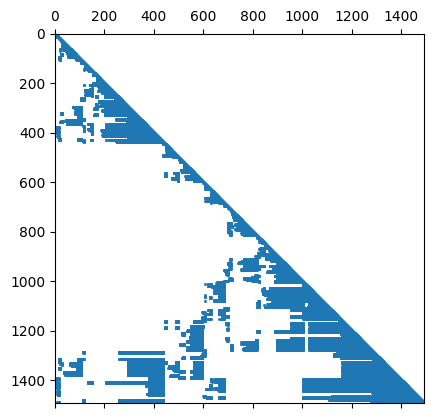

In [260]:
L = lu.L
U = lu.U

plt.spy(L, markersize=1)
plt.show()